### Import Necessary Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier, RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier, AdaBoostClassifier, BaggingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [4]:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score, make_scorer, roc_curve, auc

from imblearn.over_sampling import SMOTE

import warnings as wr
wr.filterwarnings('ignore')

> ###  Load the dataset and display some rows

In [32]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [29]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


> ### Dataset Shape 

In [30]:
df.shape

(7043, 21)

- In this dataset, there are 21 columns and 7043 rows.

> ### Basic info of the dataset

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


> # Steps to follow
1. Data Cleaning
2. EDA (Exploratory Data Analysis)
3. Feature Engineering 
4. Feature Scaling / Encoding
5. Train Test Split
6. Model Training
7. Model Evaluation

> # Data Cleaning

> ### Checking missing values

In [32]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

> ### Here, the customerID column is unnecessary. So, I will drop it.

In [33]:
df.drop('customerID',axis=1,inplace=True)

- In this dataset, there is not missing value preseent.

> ### Checking datatypes

> ### Checking duplicates present or not

In [35]:
df.duplicated().sum()

np.int64(22)

- In this dataset, there are 22 duplicate rows. I will drop these duplicate rows.

In [38]:
df.drop_duplicates(inplace=True)

In [39]:
df.shape

(7021, 20)

In [40]:
df.dtypes

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

* TotalCharges column has some non-numeric values which need to be converted to numeric


In [41]:
df['TotalCharges'] = pd.to_numeric(df.TotalCharges, errors='coerce')

In [42]:
df.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

* Here we see that the TotalCharges has 11 missing values. Let's check this data.

In [43]:
df[np.isnan(df['TotalCharges'])]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


* It can also be noted that the Tenure column is 0 for these entries even though the MonthlyCharges column is not empty.

In [44]:
df[df['tenure'] == 0].index

Index([488, 753, 936, 1082, 1340, 3331, 3826, 4380, 5218, 6670, 6754], dtype='int64')

* We can see that the rows where tenure value is 0, there totalcharges is NaN.
* There are no additional missing values in the Tenure column. 

Let's delete the rows with missing values in Tenure columns since there are only 11 rows and deleting them will not affect the data.

In [45]:
df = df.dropna()

In [46]:
df.shape

(7010, 20)

In [48]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [49]:
df.dtypes

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

> ### Outliers Checking

In [53]:
df.select_dtypes(include=['int','float'])

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
0,0,1,29.85,29.85
1,0,34,56.95,1889.50
2,0,2,53.85,108.15
3,0,45,42.30,1840.75
4,0,2,70.70,151.65
...,...,...,...,...
7038,0,24,84.80,1990.50
7039,0,72,103.20,7362.90
7040,0,11,29.60,346.45
7041,1,4,74.40,306.60


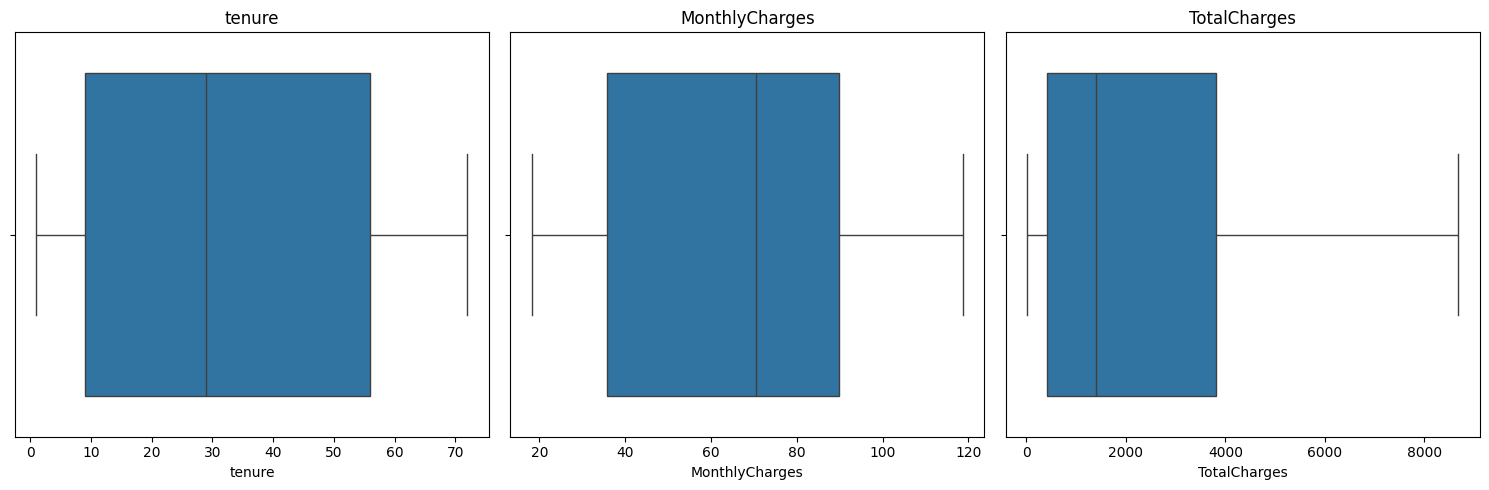

In [55]:
cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, col in enumerate(cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()


In [56]:
for col in ['tenure', 'MonthlyCharges', 'TotalCharges']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    print(f"{col} outliers:\n", outliers.values[:10])  # show first 10

tenure outliers:
 []
MonthlyCharges outliers:
 []
TotalCharges outliers:
 []


* All three boxplots show that the data is fairly well-behaved: tenure and MonthlyCharges are evenly distributed without extreme values, while TotalCharges is more spread out and slightly skewed to the right, reflecting customers with higher accumulated payments. Importantly, none of the variables have statistical outliers, meaning all values fall within the expected range of variation.


> ### Checking unique value in columns

In [61]:
cateorical_cols = df.select_dtypes(include='object').columns

In [77]:
cateorical_cols

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')

In [65]:
for i in cateorical_cols:
    print(f"{i} : {df[i].unique()}")

gender : ['Female' 'Male']
Partner : ['Yes' 'No']
Dependents : ['No' 'Yes']
PhoneService : ['No' 'Yes']
MultipleLines : ['No phone service' 'No' 'Yes']
InternetService : ['DSL' 'Fiber optic' 'No']
OnlineSecurity : ['No' 'Yes' 'No internet service']
OnlineBackup : ['Yes' 'No' 'No internet service']
DeviceProtection : ['No' 'Yes' 'No internet service']
TechSupport : ['No' 'Yes' 'No internet service']
StreamingTV : ['No' 'Yes' 'No internet service']
StreamingMovies : ['No' 'Yes' 'No internet service']
Contract : ['Month-to-month' 'One year' 'Two year']
PaperlessBilling : ['Yes' 'No']
PaymentMethod : ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn : ['No' 'Yes']


> ## Target column : Churn . Let's check the class imbalance or not

In [71]:
df['Churn'].value_counts(normalize=True)

Churn
No     0.735093
Yes    0.264907
Name: proportion, dtype: float64

> ### This dataset contains 26.49% churn yes and 73.51% churn no. That means this is an imbalanced dataset.

> # EDA (Exploratory Data Analysis)

> ### Target column visualization

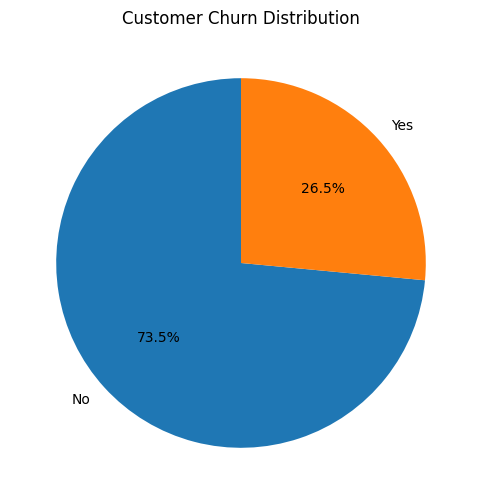

In [76]:
churn_counts = df['Churn'].value_counts()
# Plot pie chart
plt.figure(figsize=(6,6))
plt.pie(churn_counts, 
        labels=churn_counts.index, 
        autopct='%1.1f%%', 
        startangle=90)

plt.title("Customer Churn Distribution")
plt.show()

* There are more customer who did not churn than those who churned.

In [84]:
# Group by gender and churn, then count
gender_churn = df.groupby(['gender', 'Churn']).size().reset_index(name='count')
gender_churn

,gender,Churn,count
0,Female,No,2541
1,Female,Yes,934
2,Male,No,2612
3,Male,Yes,923


In [86]:
# churn ratio by gender
gender_churn_ratio = df.groupby('gender')['Churn'].value_counts(normalize=True).mul(100).unstack()
print("\nChurn ratio by gender (%):\n", gender_churn_ratio)


Churn ratio by gender (%):
 Churn          No        Yes
gender                      
Female  73.122302  26.877698
Male    73.889675  26.110325


In [87]:
# churn ratio by phoneService
phone_churn_ratio = df.groupby('PhoneService')['Churn'].value_counts(normalize=True).mul(100).unstack()
print("Churn ratio by PhoneService (%):\n", phone_churn_ratio)


Churn ratio by PhoneService (%):
 Churn                No        Yes
PhoneService                      
No            75.000000  25.000000
Yes           73.349131  26.650869


In [88]:
senior_churn_ratio = df.groupby('SeniorCitizen')['Churn'].value_counts(normalize=True).mul(100).unstack()
print("Churn ratio by SeniorCitizen (%):\n", senior_churn_ratio)

Churn ratio by SeniorCitizen (%):
 Churn                 No        Yes
SeniorCitizen                      
0              76.452547  23.547453
1              58.369851  41.630149


In [95]:
cols = ['SeniorCitizen','Partner', 'Dependents', 'MultipleLines', 
        'InternetService', 'OnlineSecurity']

for col in cols:
    churn_ratio = df.groupby(col)['Churn'].value_counts(normalize=True).mul(100).unstack()
    print(churn_ratio,"\n")


Churn                 No        Yes
SeniorCitizen                      
0              76.452547  23.547453
1              58.369851  41.630149 

Churn           No        Yes
Partner                      
No       67.155101  32.844899
Yes      80.282935  19.717065 

Churn              No        Yes
Dependents                      
No          68.825087  31.174913
Yes         84.468795  15.531205 

Churn                    No        Yes
MultipleLines                         
No                75.111508  24.888492
No phone service  75.000000  25.000000
Yes               71.351534  28.648466 

Churn                   No        Yes
InternetService                      
DSL              81.068766  18.931234
Fiber optic      58.220065  41.779935
No               92.762284   7.237716 

Churn                       No        Yes
OnlineSecurity                           
No                   58.354829  41.645171
No internet service  92.762284   7.237716
Yes                  85.359801  14.640199

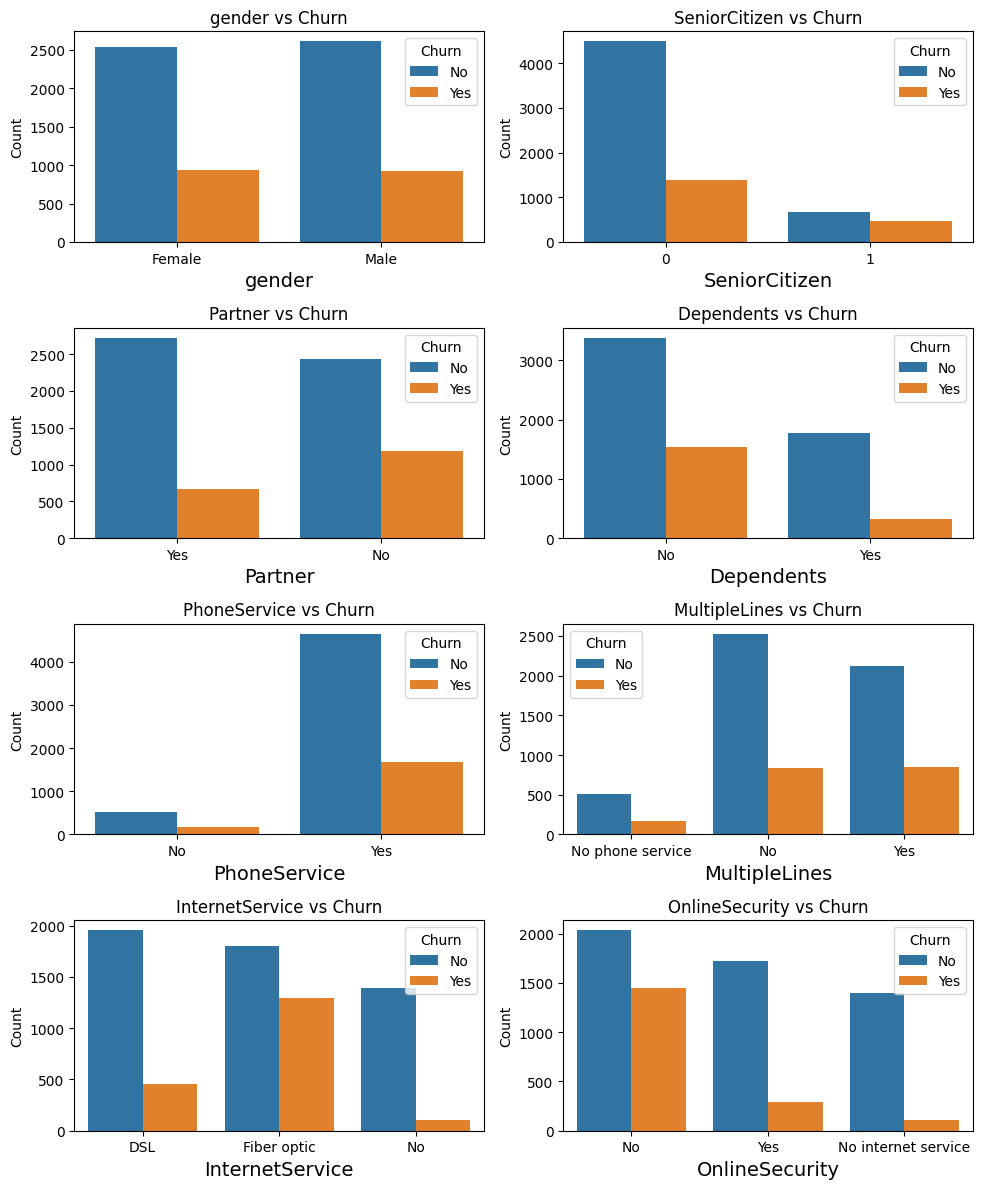

In [96]:
first_8_cat_cols = ['gender','SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity']
plt.figure(figsize=(10,12))

for i, col in enumerate(first_8_cat_cols, 1):
    plt.subplot(4, 2, i)   
    sns.countplot(x=col, hue='Churn', data=df)
    plt.title(f"{col} vs Churn")
    plt.xlabel(col,fontsize = 14)
    plt.ylabel("Count")

plt.tight_layout()
plt.show()

> ### Key Insights from the Churn Analysis
1. **Gender vs Churn**<br>
Gender shows virtually no influence on churn behavior. Male and female customers churn at nearly identical rates, making it a statistically weak feature that adds noise rather than predictive value to any model.
2. **SeniorCitizen vs Churn**<br>
Senior citizens churn at a strikingly higher rate (41.6%) compared to non-seniors (23.5%) — nearly double. This makes SeniorCitizen one of the most reliable demographic signals in the dataset and should be treated as a high-priority feature.
3. **Partner vs Churn**<br>
Customers without a partner churn at 32.8%, compared to just 19.7% for those with one. The likely explanation is that single customers have lower switching costs and fewer shared commitments tying them to the service.
4. **Dependents vs Churn**<br>
Customers with no dependents churn at 31.2%, while those with dependents churn at only 15.5%. Family responsibility appears to be a strong retention anchor — households with dependents are far more stable customers.
5. **PhoneService vs Churn**<br>
Phone service has low discriminative power. The overwhelming majority of customers have it, and churn rates are similar across both groups, offering little useful signal for prediction.
6. **MultipleLines vs Churn**<br>
Churn rates across all three MultipleLines categories (No, Yes, No phone service) cluster tightly between 24–29%. Like PhoneService, this feature contributes minimal predictive lift and can be considered for removal.
7. **InternetService vs Churn**<br>
This is the single most impactful service-level feature. Fiber optic customers churn at an alarming 41.8%, DSL customers at a moderate 18.9%, and customers with no internet at just 7.2%. The fiber optic churn rate likely reflects dissatisfaction with pricing or service quality relative to expectations.
8. **OnlineSecurity vs Churn**<br>
Customers without online security churn at 41.6% — nearly three times the 14.6% rate of those who have it. This gap suggests that security add-ons serve as an engagement and loyalty mechanism, not just a product feature.

**Overall Takeaways**

Here the gender, PhoneService, and MultipleLines — they contribute noise without meaningful signal.
I will prioritize InternetService, OnlineSecurity, SeniorCitizen, and Dependents as your core predictive features.
The highest-risk customer profile is consistent across all variables: a senior citizen, living alone, subscribed to fiber optic internet, with no security or support add-ons.

In [97]:
second_8_cols = ['OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod']
for col in second_8_cols:
    churn_ratio = df.groupby(col)['Churn'].value_counts(normalize=True).mul(100).unstack()
    print(churn_ratio,"\n")

Churn                       No        Yes
OnlineBackup                             
No                   60.214355  39.785645
No internet service  92.762284   7.237716
Yes                  78.432990  21.567010 

Churn                       No        Yes
DeviceProtection                         
No                   61.017498  38.982502
No internet service  92.762284   7.237716
Yes                  77.460711  22.539289 

Churn                       No        Yes
TechSupport                              
No                   58.487298  41.512702
No internet service  92.762284   7.237716
Yes                  84.803922  15.196078 

Churn                       No        Yes
StreamingTV                              
No                   66.654766  33.345234
No internet service  92.762284   7.237716
Yes                  69.885313  30.114687 

Churn                       No        Yes
StreamingMovies                          
No                   66.462315  33.537685
No internet service  92.76

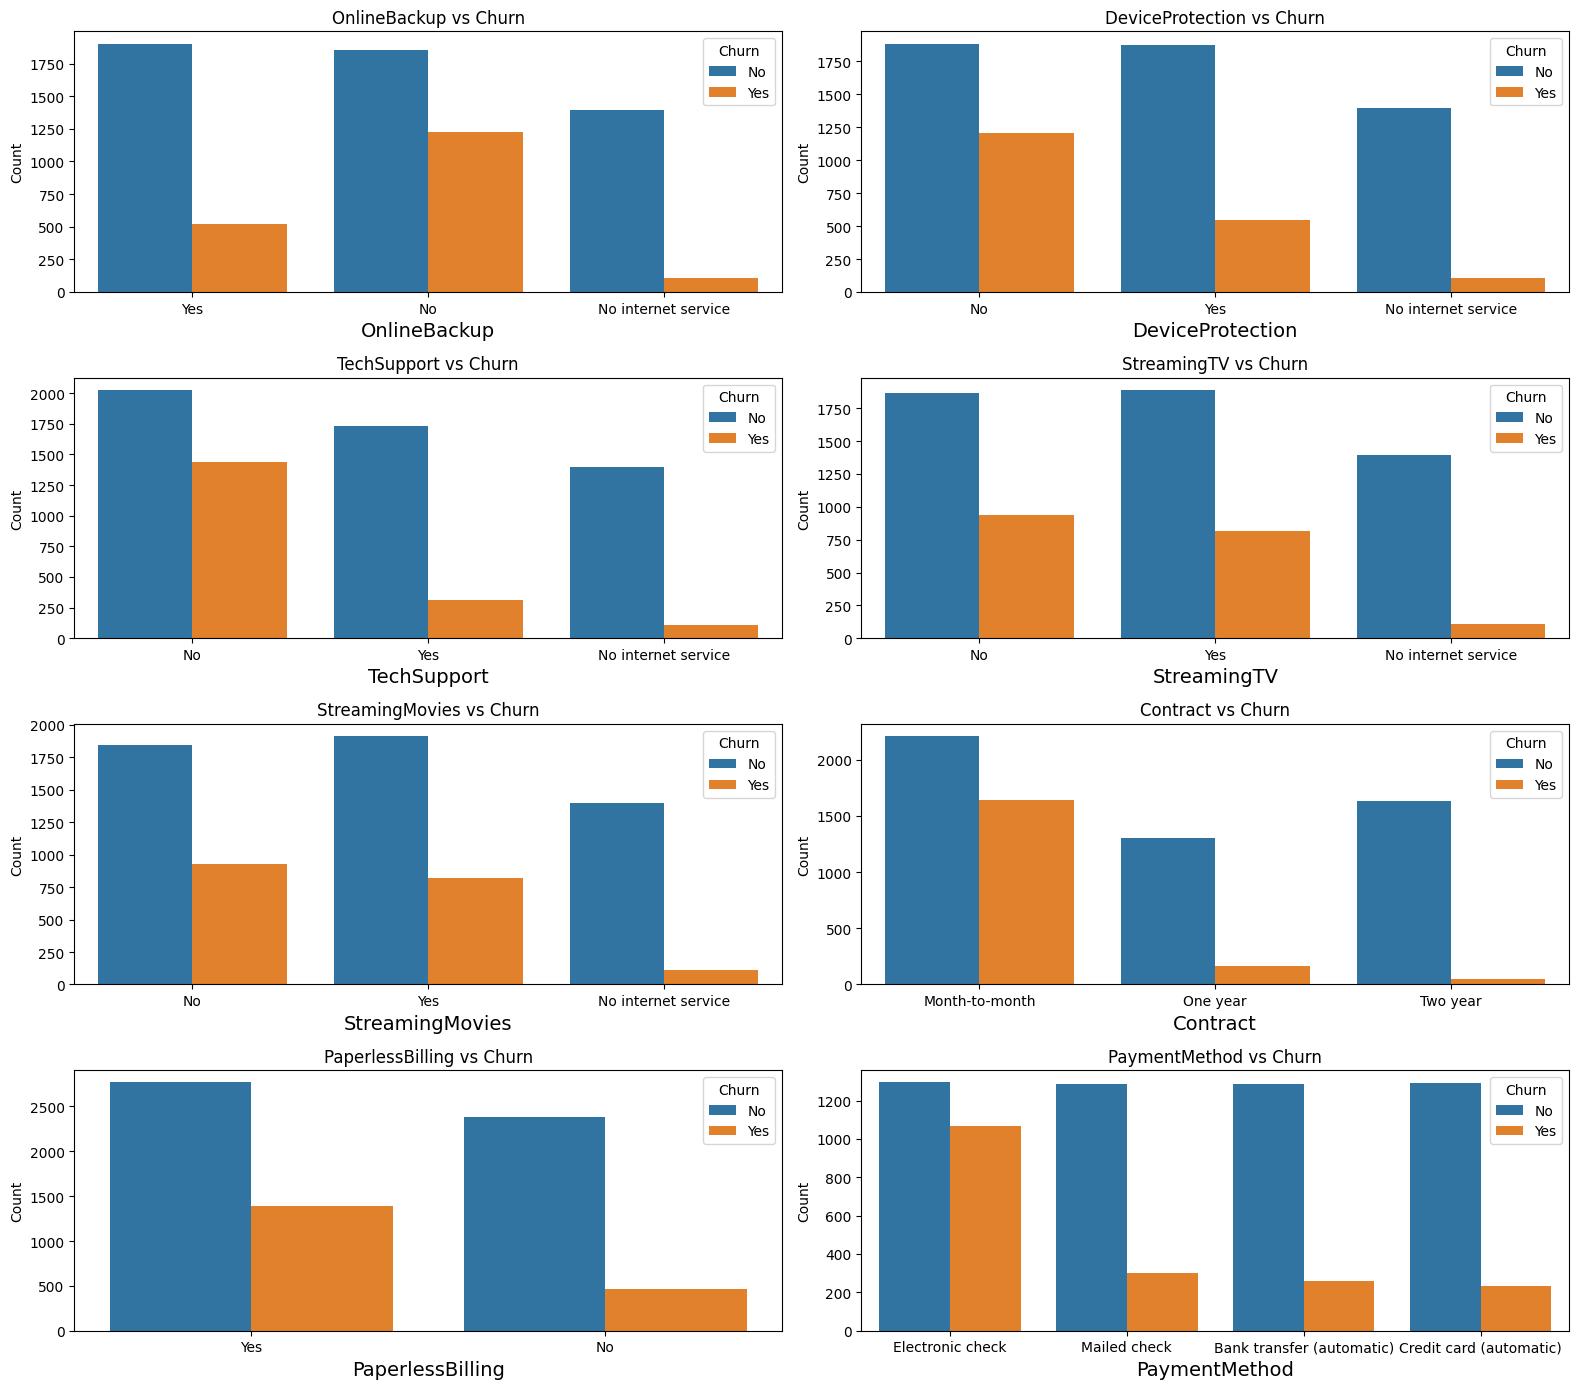

In [102]:
plt.figure(figsize=(16,14))

for i, col in enumerate(second_8_cols, 1):
    plt.subplot(4, 2, i)   
    sns.countplot(x=col, hue='Churn', data=df)
    plt.title(f"{col} vs Churn")
    plt.xlabel(col,fontsize = 14)
    plt.ylabel("Count")

plt.tight_layout()
plt.show()

> ### Key Insights from the Churn Analysis
1. **OnlineBackup vs Churn**<br>
Customers without online backup churn at 39.8%, compared to only 21.6% for those who have it. The pattern mirrors OnlineSecurity — add-on service adoption signals deeper engagement and loyalty. Customers with no internet service remain the safest segment at just 7.2%, consistent across all add-on features.
2. **DeviceProtection vs Churn**<br>
Customers without device protection churn at 39.0% versus 22.5% for those with it — a 16-point gap that is both consistent and meaningful. Like backup and security, the absence of protective add-ons reliably identifies at-risk customers, suggesting these services act as behavioral anchors rather than just product features.
3. **TechSupport vs Churn**<br>
This is one of the stronger signals in this batch. Customers without tech support churn at 41.5%, while those with it churn at only 15.2% — nearly a 3x difference. Access to support dramatically improves retention, most likely because unresolved technical frustrations are a primary trigger for cancellation decisions.
4. **StreamingTV vs Churn**<br>
StreamingTV shows almost no discriminative value. Churn rates for subscribers (30.1%) and non-subscribers (33.3%) are nearly identical, meaning customers subscribe to streaming regardless of whether they intend to stay. This feature contributes minimal predictive lift and should be considered for removal.
5. **StreamingMovies vs Churn**<br>
The result is essentially a repeat of StreamingTV — churn sits at 33.5% without it and 30.0% with it, a gap too narrow to be useful. Both streaming features move together and neither adds meaningful signal to a churn model.
6. **Contract vs Churn**<br>
This is the single most powerful feature in the entire dataset. Month-to-month customers churn at a staggering 42.6%, one-year contracts drop sharply to 11.3%, and two-year contracts are remarkably stable at just 2.8%. Contract length is the clearest behavioral signal of customer commitment — it directly reflects how "locked in" a customer feels and must be treated as the top-priority feature in any model.
7. **PaperlessBilling vs Churn**<br>
Customers on paperless billing churn at 33.5% versus 16.3% for paper billing customers. While counterintuitive, this likely reflects a customer profile effect — paperless users tend to be more digitally active, more price-aware, and more willing to comparison-shop online, making them inherently more volatile as a segment.
8. **PaymentMethod vs Churn**<br>
Electronic check customers churn at a striking 45.1% — the highest rate of any category in this entire analysis. In contrast, automatic payment methods are strongly associated with retention: bank transfer at 16.7% and credit card at 15.3%. Mailed check sits at a moderate 19.0%. Customers paying manually and inconsistently are far more likely to leave, making this feature a strong behavioral proxy for commitment level.

**Overall Takeaways**<br>
StreamingTV and StreamingMovies contribute virtually no predictive signal and should be dropped to reduce model noise.
I will prioritize Contract, PaymentMethod, TechSupport, OnlineBackup, and DeviceProtection as the core service-level features, alongside the demographic signals identified earlier.
The highest-risk customer profile is now fully defined: a month-to-month customer paying by electronic check, with no tech support, no security, no backup, subscribed to fiber optic internet — this combination represents the extreme end of churn risk in this dataset.

> ### After the Exploratory data Analysis, I understand that the gender, PhoneService, MultipleLines, StreamingTV, and StreamingMovies — they contribute noise without meaningful signal. So, I will drop them to reduce noise.

In [103]:
drop_cols = ['gender', 'PhoneService', 'MultipleLines', 
             'StreamingTV', 'StreamingMovies']
df= df.drop(columns=drop_cols)

print("Remaining columns:\n", df.columns)


Remaining columns:
 Index(['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'],
      dtype='object')


In [104]:
df.head()

,SeniorCitizen,Partner,Dependents,tenure,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Yes,No,1,DSL,No,Yes,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,0,No,No,34,DSL,Yes,No,Yes,No,One year,No,Mailed check,56.95,1889.50,No
2,0,No,No,2,DSL,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,0,No,No,45,DSL,Yes,No,Yes,Yes,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,0,No,No,2,Fiber optic,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [105]:
df.shape

(7010, 15)

> ### Convert target variable 'Churn' to binary variable 

In [33]:
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

In [31]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,NaN
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,NaN
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,NaN
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,NaN
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,NaN


In [109]:
df.select_dtypes(include='object').columns

Index(['Partner', 'Dependents', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

Churn dtype: int64
Churn unique: [0 1]

Churn ratio by Partner:
   Partner     Churn
0      No  0.329580
1     Yes  0.196649

Churn ratio by Dependents:
   Dependents     Churn
0         No  0.312791
1        Yes  0.154502

Churn ratio by InternetService:
   InternetService     Churn
0             DSL  0.189591
1     Fiber optic  0.418928
2              No  0.074050

Churn ratio by OnlineSecurity:
         OnlineSecurity     Churn
0                   No  0.417667
1  No internet service  0.074050
2                  Yes  0.146112

Churn ratio by OnlineBackup:
           OnlineBackup     Churn
0                   No  0.399288
1  No internet service  0.074050
2                  Yes  0.215315

Churn ratio by DeviceProtection:
       DeviceProtection     Churn
0                   No  0.391276
1  No internet service  0.074050
2                  Yes  0.225021

Churn ratio by TechSupport:
            TechSupport     Churn
0                   No  0.416355
1  No internet service  0.074050
2      

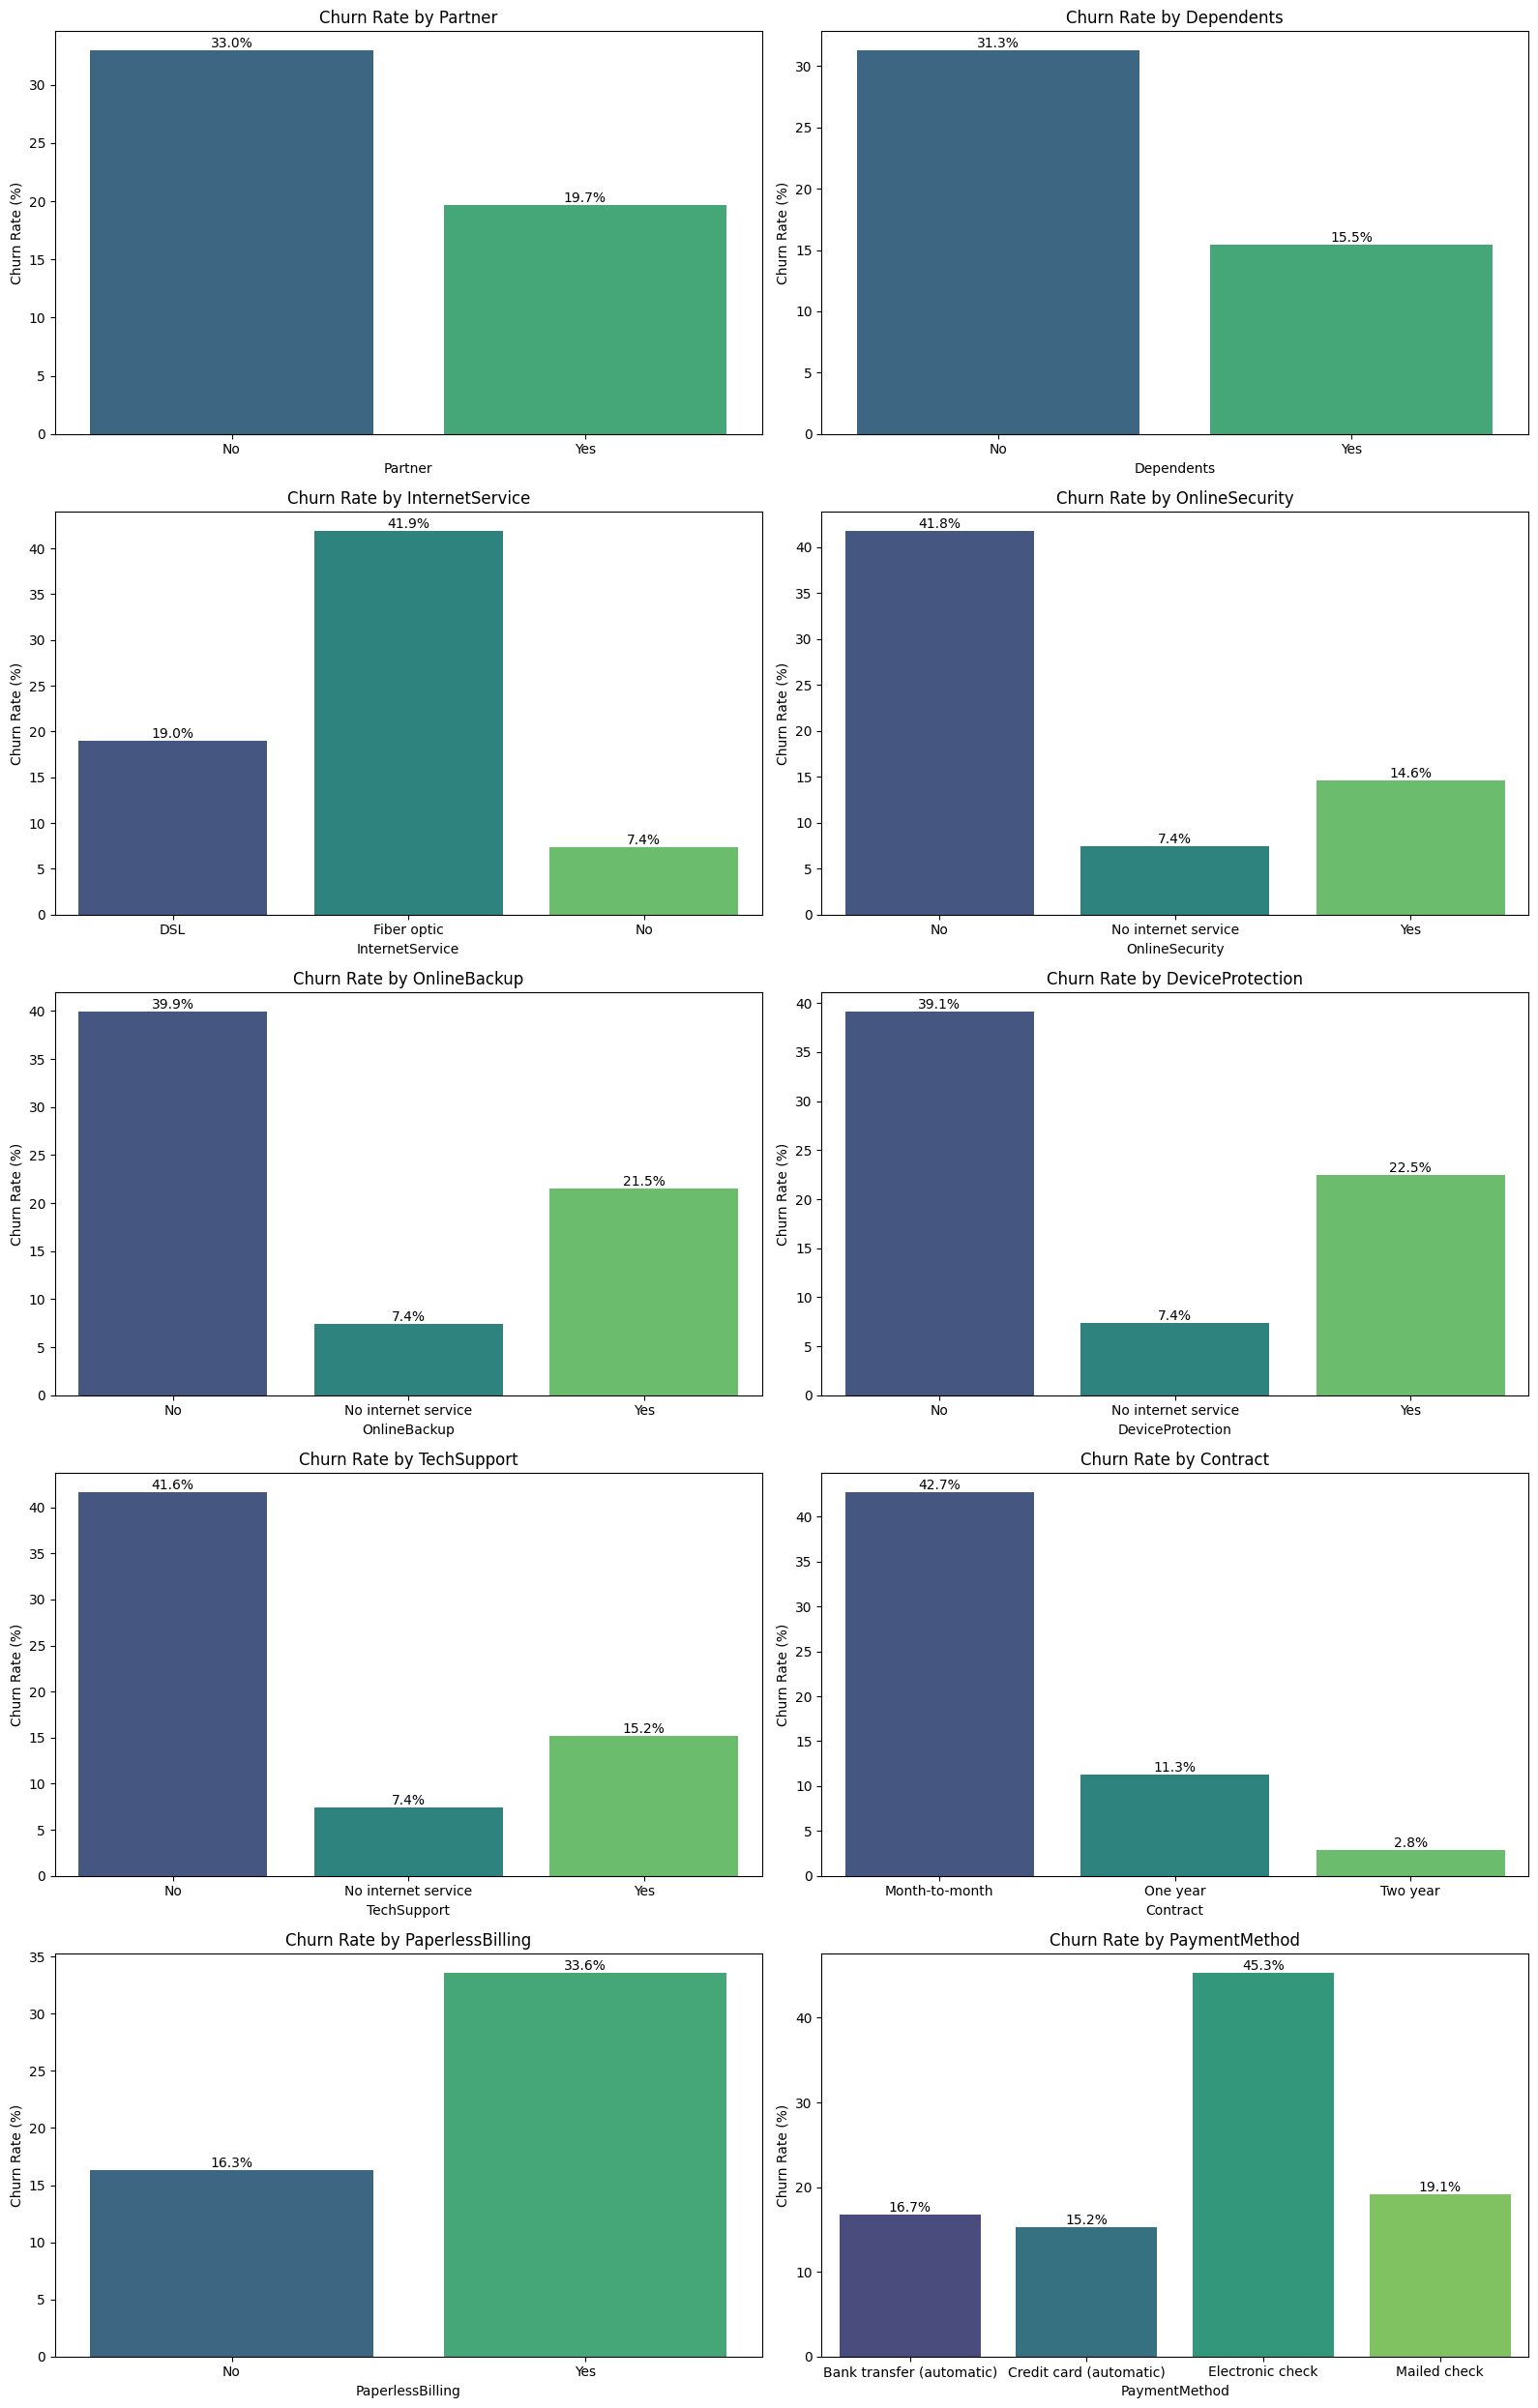

In [34]:
cols = ['Partner', 'Dependents', 'InternetService', 'OnlineSecurity',
        'OnlineBackup', 'DeviceProtection', 'TechSupport', 'Contract',
        'PaperlessBilling', 'PaymentMethod']

print("Churn dtype:", df['Churn'].dtype)
print("Churn unique:", df['Churn'].unique()[:10])

for col in cols:
    churn_ratio = df.groupby(col)['Churn'].mean().reset_index()
    print(f"\nChurn ratio by {col}:\n", churn_ratio)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(5, 2, figsize=(16, 25))
axes = axes.flatten()

for i, col in enumerate(cols):
    churn_ratio = df.groupby(col)['Churn'].mean().reset_index()
    churn_ratio['Churn'] = churn_ratio['Churn'] * 100  # Convert to percentage
    
    sns.barplot(x=col, y='Churn', data=churn_ratio, ax=axes[i], palette='viridis')
    
    axes[i].set_title(f"Churn Rate by {col}")
    axes[i].set_ylabel("Churn Rate (%)")
    axes[i].set_xlabel(col)
    
    # Add percentage labels on bars
    for p in axes[i].patches:
        axes[i].annotate(f"{p.get_height():.1f}%", 
                         (p.get_x() + p.get_width() / 2., p.get_height()), 
                         ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()